# Experiment 2.1.2 — Single-$\tau_{\mathrm{syn}}$ SNN training-objective comparison

## Scientific question

With the **same two-layer feed-forward SNN**, same unsigned event input, same user-disjoint split,
paired initialization, optimizer, and training budget:

\[
\boxed{\text{Which temporal training objective learns the gesture task most reliably?}}
\]

This experiment fixes the hidden-layer synaptic timescale to a configurable **single shift**
(default `shift_syn = 2`) and compares four objectives:

| Objective | Uses `valid_length` in loss/readout? | Temporal representation |
|---|---:|---|
| `timestep_ce` | Yes | timestep-level supervision |
| `relative_10bin_ce` | Yes | gesture-relative phase |
| `whole_window_count_ce` | No | total spike count over the full fixed window |
| `fixed_250ms_ce` | No | absolute-time fixed-duration bins over the full fixed window |

The two fixed-window objectives deliberately **do not mask by gesture end**. The network runs through
the complete padded observation window, so any short post-gesture synaptic/membrane decay tail is
retained naturally.

### Fixed backbone

\[
C \rightarrow 128 \rightarrow 128 \rightarrow K
\]

- no recurrence;
- hidden-layer `shift_syn` is one configurable scalar shared by all hidden neurons;
- SNN Linear bias = `False`;
- fixed $\tau_{mem}$, threshold, surrogate gradient, and output-layer dynamics;
- no early stopping;
- best checkpoint selected by **highest validation balanced accuracy**, tie-broken by lower validation loss;
- test set is evaluated only after checkpoint selection.


In [3]:
from __future__ import annotations

from pathlib import Path
import copy
import hashlib
import json
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingRing
PyTorch: 2.11.0+cu128
CUDA available: True


## 1. Configuration


In [4]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64",
    REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64",
]

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

# Paired master seeds. All four objectives use identical backbone initialization
# and objective-independent DataLoader order within each seed.
SEEDS = (11, 23, 101)

OBJECTIVES = (
    "timestep_ce",
    "relative_10bin_ce",
    "whole_window_count_ce",
    "fixed_250ms_ce",
)

OBJECTIVE_USES_VALID_LENGTH = {
    "timestep_ce": True,
    "relative_10bin_ce": True,
    "whole_window_count_ce": False,
    "fixed_250ms_ce": False,
}

N_RELATIVE_BINS = 10
FIXED_BIN_MS = 250.0

HIDDEN_WIDTH = 128

# Single hidden-layer tau_syn. Change only this value to sweep another single scale.
HIDDEN_SHIFT_SYN = 2

# Keep the Phase-C / Experiment-3.0 membrane, threshold, and output dynamics fixed.
TAU_MEM_MS = 22.54
TAU_SYN_OUT_MS = 77.47
THRESHOLD = 0.5
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

SPIKE_REGULARIZATION = 0.0
FIRING_ONSET_THRESHOLD = 1e-3
ZERO_INPUT_DIAGNOSTIC_STEPS = 200

BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

RESUME_EXISTING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = "experiment_2_1_2_single_tau_objective_comparison"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts" / EXPERIMENT_ID
EXPECTED_TRAINING_RUNS = len(OBJECTIVES) * len(SEEDS)

print("Experiment:", EXPERIMENT_ID)
print("Objectives:", OBJECTIVES)
print("Uses valid length:", OBJECTIVE_USES_VALID_LENGTH)
print("Seeds:", SEEDS)
print("Fixed split seed:", SPLIT_SEED)
print("Hidden width:", HIDDEN_WIDTH)
print("Hidden shift_syn:", HIDDEN_SHIFT_SYN)
print("Full trainings:", EXPECTED_TRAINING_RUNS)
print("Epoch budget:", NUM_EPOCHS)
print("Device:", DEVICE)
print("Resume existing:", RESUME_EXISTING)


Experiment: experiment_2_1_2_single_tau_objective_comparison
Objectives: ('timestep_ce', 'relative_10bin_ce', 'whole_window_count_ce', 'fixed_250ms_ce')
Uses valid length: {'timestep_ce': True, 'relative_10bin_ce': True, 'whole_window_count_ce': False, 'fixed_250ms_ce': False}
Seeds: (11, 23, 101)
Fixed split seed: 12345
Hidden width: 128
Hidden shift_syn: 2
Full trainings: 12
Epoch budget: 100
Device: cuda
Resume existing: True


## 2. Reproducibility and shift helpers


In [5]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def shift_to_alpha(shift: int) -> float:
    return float(1.0 - 2.0 ** (-int(shift)))


def alpha_to_tau_ms(alpha: float, sampling_rate_hz: float) -> float:
    dt_ms = 1000.0 / float(sampling_rate_hz)
    return float(-dt_ms / math.log(float(alpha)))


## 3. Load and validate unsigned event data


In [6]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()
for metadata in data.producer_metadatas:
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )
    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema")
    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError("event_channel_count must be positive")
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Expected six auxiliary IMU channels after event channels; "
            f"event={event_channel_count}, total={metadata.channel_count}"
        )
    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(f"Incompatible event contracts: {event_contracts}")

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

if INPUT_CHANNELS != 30:
    raise ValueError(
        f"Experiment 2.1.2 expects 30 polarity-split event channels, got {INPUT_CHANNELS}"
    )

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
padded_lengths = set()

for package_index, package in enumerate(data.packages):
    padded_lengths.add(int(package.padded_spike_imu.shape[1]))

    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError("valid_length must be positive")

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index, :valid_length, :INPUT_CHANNELS
            ]
        )
        if np.any(~np.isfinite(event_values)):
            raise ValueError("Non-finite event values")
        if np.any(event_values < 0.0):
            raise ValueError(
                "Unsigned event contract violated for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

if len(padded_lengths) != 1:
    raise ValueError(f"Expected one padded length, got {padded_lengths}")
PADDED_LENGTH = padded_lengths.pop()

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after label filtering")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
NUM_CLASSES = len(CLASS_TO_IDX)

DT_MS = 1000.0 / SAMPLING_RATE_HZ
HIDDEN_ALPHA = shift_to_alpha(HIDDEN_SHIFT_SYN)
HIDDEN_TAU_SYN_MS = alpha_to_tau_ms(HIDDEN_ALPHA, SAMPLING_RATE_HZ)
BETA = float(math.exp(-DT_MS / TAU_MEM_MS))
OUTPUT_ALPHA = float(math.exp(-DT_MS / TAU_SYN_OUT_MS))

FIXED_BIN_STEPS = max(
    1,
    int(round(FIXED_BIN_MS * SAMPLING_RATE_HZ / 1000.0)),
)
FIXED_BIN_EFFECTIVE_MS = 1000.0 * FIXED_BIN_STEPS / SAMPLING_RATE_HZ
FIXED_BIN_COUNT = int(math.ceil(PADDED_LENGTH / FIXED_BIN_STEPS))
FIXED_BIN_PADDED_STEPS = FIXED_BIN_COUNT * FIXED_BIN_STEPS

print(f"samples={len(manifest)}, users={manifest.user.nunique()}, classes={NUM_CLASSES}")
print(f"input_channels={INPUT_CHANNELS}")
print(f"sampling_rate={SAMPLING_RATE_HZ} Hz, padded_length={PADDED_LENGTH}")
print(
    f"hidden shift={HIDDEN_SHIFT_SYN}, alpha={HIDDEN_ALPHA:.6f}, "
    f"tau_syn={HIDDEN_TAU_SYN_MS:.3f} ms"
)
print(
    f"beta={BETA:.6f}, output_alpha={OUTPUT_ALPHA:.6f}, "
    f"threshold={THRESHOLD}"
)
print(
    f"fixed bin requested={FIXED_BIN_MS:.1f} ms, "
    f"implemented={FIXED_BIN_STEPS} samples="
    f"{FIXED_BIN_EFFECTIVE_MS:.3f} ms, bins={FIXED_BIN_COUNT}, "
    f"aggregation padded steps={FIXED_BIN_PADDED_STEPS}"
)


samples=853, users=20, classes=12
input_channels=30
sampling_rate=64.0 Hz, padded_length=256
hidden shift=2, alpha=0.750000, tau_syn=54.313 ms
beta=0.499968, output_alpha=0.817347, threshold=0.5
fixed bin requested=250.0 ms, implemented=16 samples=250.000 ms, bins=16, aggregation padded steps=256


## 4. One fixed user-disjoint split


In [7]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train, n_val = n - 2, 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else (
            "val" if u in val_users else "test"
        )
    )
    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

split_summary = FIXED_SPLIT_MANIFEST.groupby("split").agg(
    users=("user", "nunique"),
    samples=("label", "size"),
    classes_present=("label", "nunique"),
)
display(split_summary)

for split_name in ("train", "val", "test"):
    n_classes = int(
        FIXED_SPLIT_MANIFEST.loc[
            FIXED_SPLIT_MANIFEST.split == split_name,
            "label",
        ].nunique()
    )
    if n_classes != NUM_CLASSES:
        raise ValueError(
            f"Split {split_name!r} contains {n_classes}/{NUM_CLASSES} classes"
        )


,users,samples,classes_present
split,,,
test,3,146,12
train,14,581,12
val,3,126,12


## 5. Dataset and paired DataLoaders


In [8]:
class EventSNNDataset(Dataset):
    def __init__(self, data, subset_manifest: pd.DataFrame):
        self.data = data
        self.df = subset_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index, :, :INPUT_CHANNELS
            ],
            dtype=np.float32,
        ).copy()

        if x.shape != (PADDED_LENGTH, INPUT_CHANNELS):
            raise ValueError(f"Unexpected input shape {x.shape}")
        if np.any(x[:valid_length] < 0.0):
            raise ValueError("Unsigned event contract violated")

        # Enforce the fixed-window input contract: the padded observation tail is zero input.
        # The fixed-window objectives still aggregate ALL model outputs over PADDED_LENGTH;
        # they never mask their loss/readout by valid_length.
        x[valid_length:] = 0.0
        valid_mask = np.arange(PADDED_LENGTH) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loader(
    subset_manifest: pd.DataFrame,
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
):
    dataset = EventSNNDataset(data, subset_manifest)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=generator,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        pin_memory=torch.cuda.is_available(),
    )


def make_split_loaders(master_seed: int, include_test: bool = False):
    specs = [
        ("train", "train", True),
        ("train_eval", "train", False),
        ("val", "val", False),
    ]
    if include_test:
        specs.append(("test", "test", False))

    loaders = {}
    for name, split_name, shuffle in specs:
        subset = FIXED_SPLIT_MANIFEST[
            FIXED_SPLIT_MANIFEST.split == split_name
        ]
        loaders[name] = make_loader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            # Deliberately objective-independent for paired runs.
            seed=derive_seed(master_seed, name, "loader"),
        )
    return loaders


## 6. Temporal aggregation helpers

`relative_10bin_ce` is boundary-aware and uses only the valid gesture duration.

`fixed_250ms_ce` is boundary-free: it bins the **entire fixed observation window**. At 64 Hz,
200 ms maps to 12.8 samples, so the implementation uses `round(...) = 13` samples per bin
($203.125$ ms effective duration). If the final bin is incomplete, zero padding is added only
inside the aggregation helper so the SNN itself still runs exactly `PADDED_LENGTH` timesteps.


In [9]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    """Return [B, n_bins, K] counts over gesture-relative valid-time bins."""
    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(output_spikes.device, dtype=torch.long)

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(
        bin_index,
        num_classes=n_bins,
    ).to(output_spikes.dtype)
    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)

    return torch.einsum("btn,btk->bnk", one_hot, output_spikes)


def fixed_window_bin_counts(output_spikes: torch.Tensor) -> torch.Tensor:
    """Return [B, fixed_bins, K] counts over the complete fixed observation window."""
    batch_size, time_steps, class_count = output_spikes.shape
    if time_steps != PADDED_LENGTH:
        raise ValueError(
            f"Expected {PADDED_LENGTH} timesteps, got {time_steps}"
        )

    if FIXED_BIN_PADDED_STEPS > time_steps:
        output_spikes = F.pad(
            output_spikes,
            (0, 0, 0, FIXED_BIN_PADDED_STEPS - time_steps),
        )

    return output_spikes.reshape(
        batch_size,
        FIXED_BIN_COUNT,
        FIXED_BIN_STEPS,
        class_count,
    ).sum(dim=2)


def whole_window_counts(output_spikes: torch.Tensor) -> torch.Tensor:
    """Sum over every timestep in the fixed observation window, with no valid mask."""
    return output_spikes.sum(dim=1)


## 7. Fixed single-$\tau_{\mathrm{syn}}$ two-layer SNN

All hidden neurons use the same configurable `HIDDEN_SHIFT_SYN` (default 2). The output layer keeps
the same fixed dynamics used in Experiment 3.0. Only the objective/readout changes across runs.


In [10]:
class SingleTauObjectiveSNN(nn.Module):
    def __init__(
        self,
        *,
        objective: str,
        num_classes: int,
        input_channels: int,
        master_seed: int,
    ):
        super().__init__()

        if objective not in OBJECTIVES:
            raise ValueError(f"Unknown objective: {objective}")

        self.objective = str(objective)
        self.width = int(HIDDEN_WIDTH)
        self.depth = 2
        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        # Paired backbone initialization across all objectives within a master seed.
        seed_everything(derive_seed(master_seed, "shared_backbone_init"))

        self.fc1 = nn.Linear(input_channels, HIDDEN_WIDTH, bias=False)
        self.lif1 = snn.Synaptic(
            alpha=HIDDEN_ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif2 = snn.Synaptic(
            alpha=HIDDEN_ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(HIDDEN_WIDTH, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=OUTPUT_ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.readout_head = None

        if self.objective == "relative_10bin_ce":
            seed_everything(derive_seed(master_seed, self.objective, "head_init"))
            self.readout_head = nn.Linear(
                N_RELATIVE_BINS * num_classes,
                num_classes,
                bias=True,
            )
        elif self.objective == "fixed_250ms_ce":
            seed_everything(derive_seed(master_seed, self.objective, "head_init"))
            self.readout_head = nn.Linear(
                FIXED_BIN_COUNT * num_classes,
                num_classes,
                bias=True,
            )

    @property
    def backbone_parameter_count(self) -> int:
        modules = [self.fc1, self.fc2, self.fc_out]
        return sum(
            p.numel()
            for module in modules
            for p in module.parameters()
        )

    @property
    def readout_parameter_count(self) -> int:
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    @property
    def spike_neuron_count(self) -> int:
        return 2 * HIDDEN_WIDTH + self.num_classes

    def forward(self, x, valid_mask=None):
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        spk1_rec = []
        spk2_rec = []
        out_rec = []

        for step in range(x.shape[1]):
            h1, _, _ = self.lif1(self.fc1(x[:, step, :]))
            h2, _, _ = self.lif2(self.fc2(h1))
            spk_out, _, _ = self.lif_out(self.fc_out(h2))

            spk1_rec.append(h1)
            spk2_rec.append(h2)
            out_rec.append(spk_out)

        hidden_spikes = [
            torch.stack(spk1_rec, dim=1),
            torch.stack(spk2_rec, dim=1),
        ]
        output_spikes = torch.stack(out_rec, dim=1)

        return {
            "hidden_spikes": hidden_spikes,
            "output_spikes": output_spikes,
        }

    def native_logits(
        self,
        out,
        valid_lengths,
        valid_mask=None,
    ):
        output_spikes = out["output_spikes"]

        if self.objective == "timestep_ce":
            if valid_mask is None:
                t = torch.arange(
                    output_spikes.shape[1],
                    device=output_spikes.device,
                )[None, :]
                valid_mask = t < valid_lengths[:, None]

            return (
                output_spikes
                * valid_mask.unsqueeze(-1).to(output_spikes.dtype)
            ).sum(dim=1)

        if self.objective == "relative_10bin_ce":
            bins = relative_temporal_bin_counts(
                output_spikes,
                valid_lengths,
                N_RELATIVE_BINS,
            )
            return self.readout_head(bins.flatten(start_dim=1))

        if self.objective == "whole_window_count_ce":
            # Deliberately no valid mask / valid length.
            return whole_window_counts(output_spikes)

        if self.objective == "fixed_250ms_ce":
            # Deliberately no valid mask / valid length.
            bins = fixed_window_bin_counts(output_spikes)
            return self.readout_head(bins.flatten(start_dim=1))

        raise RuntimeError(self.objective)

    def training_loss(
        self,
        out,
        labels,
        valid_mask,
        valid_lengths,
    ):
        output_spikes = out["output_spikes"]

        if self.objective == "timestep_ce":
            batch_size, time_steps, class_count = output_spikes.shape
            targets = labels[:, None].expand(batch_size, time_steps)

            loss_per_step = F.cross_entropy(
                output_spikes.reshape(batch_size * time_steps, class_count),
                targets.reshape(batch_size * time_steps),
                reduction="none",
            ).reshape(batch_size, time_steps)

            mask_f = valid_mask.to(loss_per_step.dtype)
            loss = (
                (loss_per_step * mask_f).sum()
                / mask_f.sum().clamp_min(1)
            )

        elif self.objective == "relative_10bin_ce":
            logits = self.native_logits(
                out,
                valid_lengths,
                valid_mask,
            )
            loss = F.cross_entropy(logits, labels)

        elif self.objective in {
            "whole_window_count_ce",
            "fixed_250ms_ce",
        }:
            # These objectives intentionally ignore valid_length in the readout/loss.
            logits = self.native_logits(
                out,
                valid_lengths,
                valid_mask=None,
            )
            loss = F.cross_entropy(logits, labels)

        else:
            raise RuntimeError(self.objective)

        if SPIKE_REGULARIZATION > 0:
            # Optional regularizer remains valid-region based so padding does not encourage activity.
            mask_f = valid_mask.unsqueeze(-1).to(output_spikes.dtype)
            valid_spikes = (
                sum((spikes * mask_f).sum() for spikes in out["hidden_spikes"])
                + (output_spikes * mask_f).sum()
            )
            valid_neuron_time = (
                valid_mask.to(output_spikes.dtype).sum().clamp_min(1)
                * self.spike_neuron_count
            )
            loss = (
                loss
                + SPIKE_REGULARIZATION
                * valid_spikes
                / valid_neuron_time
            )

        return loss


## 8. Metrics, fixed-window diagnostics, and zero-input activity


In [11]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    sample_count = 0
    valid_steps = 0
    full_steps = 0
    y_true, y_pred = [], []

    hidden_valid_totals = [0.0, 0.0]
    hidden_full_totals = [0.0, 0.0]
    output_valid_total = 0.0
    output_full_total = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)
        logits = model.native_logits(out, lengths, mask)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        batch_valid_steps = int(mask.sum().item())
        batch_full_steps = batch_size * out["output_spikes"].shape[1]

        total_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        valid_steps += batch_valid_steps
        full_steps += batch_full_steps

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        mask_f = mask.unsqueeze(-1).to(out["output_spikes"].dtype)

        for layer_idx, spikes in enumerate(out["hidden_spikes"]):
            hidden_valid_totals[layer_idx] += float(
                (spikes * mask_f).sum().item()
            )
            hidden_full_totals[layer_idx] += float(spikes.sum().item())

        batch_out_valid = (
            out["output_spikes"] * mask_f
        ).sum(dim=(1, 2))
        batch_out_full = out["output_spikes"].sum(dim=(1, 2))

        output_valid_total += float(batch_out_valid.sum().item())
        output_full_total += float(batch_out_full.sum().item())
        silent_output_samples += int((batch_out_full == 0).sum().item())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(sample_count, 1)

    for layer_idx in range(2):
        metrics[f"hidden_{layer_idx + 1}_firing_rate"] = (
            hidden_valid_totals[layer_idx]
            / max(valid_steps * HIDDEN_WIDTH, 1)
        )
        metrics[f"hidden_{layer_idx + 1}_full_window_firing_rate"] = (
            hidden_full_totals[layer_idx]
            / max(full_steps * HIDDEN_WIDTH, 1)
        )

    metrics["output_firing_rate"] = (
        output_valid_total / max(valid_steps * NUM_CLASSES, 1)
    )
    metrics["output_full_window_firing_rate"] = (
        output_full_total / max(full_steps * NUM_CLASSES, 1)
    )
    metrics["silent_output_fraction"] = (
        silent_output_samples / max(sample_count, 1)
    )
    metrics["samples"] = sample_count
    return metrics


@torch.no_grad()
def evaluate_common_whole_window_count(model, loader):
    """Same parameter-free full-window spike-count rule for every trained backbone."""
    model.eval()
    y_true, y_pred = [], []

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        counts = whole_window_counts(out["output_spikes"])
        pred = counts.argmax(dim=1)

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

    return classification_metrics(y_true, y_pred)


@torch.no_grad()
def zero_input_activity(
    model,
    steps=ZERO_INPUT_DIAGNOSTIC_STEPS,
):
    model.eval()

    x = torch.zeros(
        1,
        steps,
        INPUT_CHANNELS,
        device=DEVICE,
    )
    mask = torch.ones(
        1,
        steps,
        dtype=torch.bool,
        device=DEVICE,
    )

    out = model(x, mask)

    return {
        "zero_hidden_1_firing_rate": float(
            out["hidden_spikes"][0].mean().item()
        ),
        "zero_hidden_2_firing_rate": float(
            out["hidden_spikes"][1].mean().item()
        ),
        "zero_output_firing_rate": float(
            out["output_spikes"].mean().item()
        ),
    }


## 9. Fixed-budget training and best-validation-BA checkpoint


In [12]:
def _cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def train_one_objective(
    *,
    objective: str,
    master_seed: int,
    train_loader,
    train_eval_loader,
    val_loader,
):
    model = SingleTauObjectiveSNN(
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_ba = -np.inf
    best_val_loss = np.inf
    best_epoch = -1
    firing_onset_epoch = None
    history_rows = []

    zero_before = zero_input_activity(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()

        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)
            mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
            lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            out = model(x, mask)
            loss = model.training_loss(
                out,
                y,
                mask,
                lengths,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for objective={objective}, seed={master_seed}"
                )

            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

            optimizer.step()

        train_metrics = evaluate_model(model, train_eval_loader)
        val_metrics = evaluate_model(model, val_loader)

        if (
            firing_onset_epoch is None
            and val_metrics["output_firing_rate"] > FIRING_ONSET_THRESHOLD
        ):
            firing_onset_epoch = epoch

        val_ba = val_metrics["balanced_accuracy"]
        val_loss = val_metrics["loss"]

        improved = (
            val_ba > best_val_ba + 1e-12
            or (
                abs(val_ba - best_val_ba) <= 1e-12
                and val_loss < best_val_loss - 1e-12
            )
        )

        if improved:
            best_val_ba = val_ba
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = _cpu_state_dict(model)

        history_rows.append(
            {
                "objective": objective,
                "seed": master_seed,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_balanced_accuracy": train_metrics["balanced_accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_hidden_1_firing_rate": train_metrics["hidden_1_firing_rate"],
                "train_hidden_2_firing_rate": train_metrics["hidden_2_firing_rate"],
                "train_output_firing_rate": train_metrics["output_firing_rate"],
                "train_output_full_window_firing_rate": train_metrics[
                    "output_full_window_firing_rate"
                ],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_hidden_1_firing_rate": val_metrics["hidden_1_firing_rate"],
                "val_hidden_2_firing_rate": val_metrics["hidden_2_firing_rate"],
                "val_output_firing_rate": val_metrics["output_firing_rate"],
                "val_output_full_window_firing_rate": val_metrics[
                    "output_full_window_firing_rate"
                ],
                "val_silent_output_fraction": val_metrics["silent_output_fraction"],
            }
        )

        if epoch == 1 or epoch % 10 == 0 or epoch == NUM_EPOCHS:
            print(
                f"epoch {epoch:>3d} | "
                f"train loss={train_metrics['loss']:.4f} "
                f"train BA={train_metrics['balanced_accuracy']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} "
                f"val BA={val_metrics['balanced_accuracy']:.4f} | "
                f"L1 FR={val_metrics['hidden_1_firing_rate']:.4f} "
                f"L2 FR={val_metrics['hidden_2_firing_rate']:.4f} "
                f"out FR={val_metrics['output_firing_rate']:.4f}"
            )

    if best_state is None:
        raise RuntimeError("No best checkpoint selected")

    model.load_state_dict(best_state)
    zero_after = zero_input_activity(model)

    return {
        "model": model,
        "history": pd.DataFrame(history_rows),
        "best_epoch": best_epoch,
        "best_val_ba": best_val_ba,
        "best_val_loss": best_val_loss,
        "firing_onset_epoch": firing_onset_epoch,
        "zero_before": zero_before,
        "zero_after": zero_after,
    }


## 10. Persistent checkpoints / resume


In [13]:
def objective_tag(objective: str) -> str:
    mapping = {
        "timestep_ce": "timestep",
        "relative_10bin_ce": "relative10bin",
        "whole_window_count_ce": "whole_window_count",
        "fixed_250ms_ce": "fixed200ms",
    }
    if objective not in mapping:
        raise ValueError(objective)
    return mapping[objective]


def checkpoint_path(objective: str, master_seed: int):
    return (
        RESULTS_DIR
        / "checkpoints"
        / (
            f"{objective_tag(objective)}_"
            f"seed_{master_seed}_"
            f"shift_{HIDDEN_SHIFT_SYN}_"
            f"width_{HIDDEN_WIDTH}_best_val_ba.pt"
        )
    )


def history_path(objective: str, master_seed: int):
    return (
        RESULTS_DIR
        / "histories"
        / (
            f"{objective_tag(objective)}_"
            f"seed_{master_seed}_"
            f"shift_{HIDDEN_SHIFT_SYN}_"
            f"width_{HIDDEN_WIDTH}_history.csv"
        )
    )


def checkpoint_contract(objective: str, master_seed: int):
    return {
        "experiment_id": EXPERIMENT_ID,
        "objective": objective,
        "objective_uses_valid_length": bool(
            OBJECTIVE_USES_VALID_LENGTH[objective]
        ),
        "seed": int(master_seed),
        "split_seed": int(SPLIT_SEED),
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "hidden_width": int(HIDDEN_WIDTH),
        "hidden_shift_syn": int(HIDDEN_SHIFT_SYN),
        "hidden_alpha": float(HIDDEN_ALPHA),
        "hidden_tau_syn_ms": float(HIDDEN_TAU_SYN_MS),
        "n_relative_bins": int(N_RELATIVE_BINS),
        "fixed_bin_requested_ms": float(FIXED_BIN_MS),
        "fixed_bin_steps": int(FIXED_BIN_STEPS),
        "fixed_bin_effective_ms": float(FIXED_BIN_EFFECTIVE_MS),
        "fixed_bin_count": int(FIXED_BIN_COUNT),
        "padded_length": int(PADDED_LENGTH),
        "tau_mem_ms": float(TAU_MEM_MS),
        "tau_syn_out_ms": float(TAU_SYN_OUT_MS),
        "threshold": float(THRESHOLD),
        "sampling_rate_hz": float(SAMPLING_RATE_HZ),
        "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    }


def save_completed_run(objective: str, master_seed: int, run):
    checkpoint_path(objective, master_seed).parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    history_path(objective, master_seed).parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    payload = checkpoint_contract(objective, master_seed)
    payload.update(
        {
            "best_epoch": int(run["best_epoch"]),
            "best_val_ba": float(run["best_val_ba"]),
            "best_val_loss": float(run["best_val_loss"]),
            "firing_onset_epoch": run["firing_onset_epoch"],
            "zero_before": run["zero_before"],
            "zero_after": run["zero_after"],
            "state_dict": _cpu_state_dict(run["model"]),
        }
    )

    torch.save(payload, checkpoint_path(objective, master_seed))
    run["history"].to_csv(
        history_path(objective, master_seed),
        index=False,
    )


def load_completed_run(objective: str, master_seed: int):
    ckpt = checkpoint_path(objective, master_seed)
    hist = history_path(objective, master_seed)

    if not (ckpt.exists() and hist.exists()):
        return None

    payload = torch.load(
        ckpt,
        map_location="cpu",
        weights_only=False,
    )

    required = checkpoint_contract(objective, master_seed)
    for key, expected in required.items():
        if payload.get(key) != expected:
            raise ValueError(
                f"Checkpoint mismatch for {ckpt}: "
                f"{key}={payload.get(key)!r}, expected {expected!r}. "
                "Delete the stale checkpoint or change RESULTS_DIR."
            )

    model = SingleTauObjectiveSNN(
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)
    model.load_state_dict(payload["state_dict"])

    return {
        "model": model,
        "history": pd.read_csv(hist),
        "best_epoch": int(payload["best_epoch"]),
        "best_val_ba": float(payload["best_val_ba"]),
        "best_val_loss": float(payload["best_val_loss"]),
        "firing_onset_epoch": payload.get("firing_onset_epoch"),
        "zero_before": payload.get("zero_before", {}),
        "zero_after": payload.get("zero_after", {}),
    }


## 11. Objective $\times$ seed sweep

This cell performs all 12 full trainings for the default three paired seeds. The split is fixed by
`SPLIT_SEED`. Within each master seed, all objectives use the same DataLoader order and identical
backbone initialization. The test loader is created only after the best validation-BA checkpoint is
available.


In [14]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

run_rows = []
history_frames = []

for master_seed in SEEDS:
    print("=" * 100)
    print("MASTER SEED:", master_seed)

    for objective in OBJECTIVES:
        print("-" * 100)
        print("OBJECTIVE:", objective)
        print("USES VALID LENGTH:", OBJECTIVE_USES_VALID_LENGTH[objective])

        loaders = make_split_loaders(master_seed, include_test=False)

        run = (
            load_completed_run(objective, master_seed)
            if RESUME_EXISTING
            else None
        )

        if run is None:
            run = train_one_objective(
                objective=objective,
                master_seed=master_seed,
                train_loader=loaders["train"],
                train_eval_loader=loaders["train_eval"],
                val_loader=loaders["val"],
            )
            save_completed_run(objective, master_seed, run)
        else:
            print(
                f"Loaded completed checkpoint: best epoch={run['best_epoch']}, "
                f"best val BA={run['best_val_ba']:.4f}"
            )

        model = run["model"]
        history_frames.append(run["history"])

        # Test is touched only after checkpoint selection / resume validation.
        test_loader = make_split_loaders(
            master_seed,
            include_test=True,
        )["test"]

        split_metrics = {
            "train": evaluate_model(model, loaders["train_eval"]),
            "val": evaluate_model(model, loaders["val"]),
            "test": evaluate_model(model, test_loader),
        }

        common_whole_window = {
            "train": evaluate_common_whole_window_count(
                model, loaders["train_eval"]
            ),
            "val": evaluate_common_whole_window_count(
                model, loaders["val"]
            ),
            "test": evaluate_common_whole_window_count(
                model, test_loader
            ),
        }

        row = {
            "experiment": EXPERIMENT_ID,
            "objective": objective,
            "uses_valid_length": OBJECTIVE_USES_VALID_LENGTH[objective],
            "seed": master_seed,
            "best_epoch": run["best_epoch"],
            "best_val_ba": run["best_val_ba"],
            "val_loss_at_best_val_ba": run["best_val_loss"],
            "firing_onset_epoch": (
                np.nan
                if run["firing_onset_epoch"] is None
                else run["firing_onset_epoch"]
            ),
            "input_channels": INPUT_CHANNELS,
            "hidden_width": HIDDEN_WIDTH,
            "hidden_shift_syn": HIDDEN_SHIFT_SYN,
            "hidden_tau_syn_ms": HIDDEN_TAU_SYN_MS,
            "num_classes": NUM_CLASSES,
            "backbone_params": model.backbone_parameter_count,
            "readout_params": model.readout_parameter_count,
            "total_params": model.total_parameter_count,
            **run["zero_after"],
        }

        for split_name, metrics in split_metrics.items():
            for metric_name, value in metrics.items():
                row[f"{split_name}_{metric_name}"] = value

        for split_name, metrics in common_whole_window.items():
            for metric_name, value in metrics.items():
                row[
                    f"{split_name}_common_whole_window_{metric_name}"
                ] = value

        run_rows.append(row)

        print(
            f"best epoch={run['best_epoch']} | "
            f"train BA={split_metrics['train']['balanced_accuracy']:.4f} | "
            f"val BA={split_metrics['val']['balanced_accuracy']:.4f} | "
            f"test BA={split_metrics['test']['balanced_accuracy']:.4f} | "
            f"common whole-window test BA="
            f"{common_whole_window['test']['balanced_accuracy']:.4f}"
        )
        print("zero-input after best checkpoint:", run["zero_after"])

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(run_rows)
histories_df = pd.concat(history_frames, ignore_index=True)

display(results_df)


MASTER SEED: 11
----------------------------------------------------------------------------------------------------
OBJECTIVE: timestep_ce
USES VALID LENGTH: True
epoch   1 | train loss=2.4849 train BA=0.0833 | val loss=2.4849 val BA=0.0833 | L1 FR=0.0000 L2 FR=0.0000 out FR=0.0000
epoch  10 | train loss=2.4828 train BA=0.0974 | val loss=2.4849 val BA=0.0833 | L1 FR=0.0001 L2 FR=0.0000 out FR=0.0000
epoch  20 | train loss=2.4762 train BA=0.1338 | val loss=2.4799 val BA=0.1200 | L1 FR=0.0004 L2 FR=0.0004 out FR=0.0012
epoch  30 | train loss=2.4456 train BA=0.1734 | val loss=2.4587 val BA=0.1329 | L1 FR=0.0015 L2 FR=0.0064 out FR=0.0192
epoch  40 | train loss=2.4171 train BA=0.2272 | val loss=2.4447 val BA=0.1865 | L1 FR=0.0024 L2 FR=0.0133 out FR=0.0434
epoch  50 | train loss=2.3857 train BA=0.2676 | val loss=2.4273 val BA=0.1627 | L1 FR=0.0035 L2 FR=0.0238 out FR=0.0671
epoch  60 | train loss=2.3558 train BA=0.3530 | val loss=2.4122 val BA=0.2058 | L1 FR=0.0045 L2 FR=0.0334 out FR=0.0

,experiment,objective,uses_valid_length,seed,best_epoch,best_val_ba,val_loss_at_best_val_ba,firing_onset_epoch,input_channels,hidden_width,...,test_samples,train_common_whole_window_accuracy,train_common_whole_window_balanced_accuracy,train_common_whole_window_macro_f1,val_common_whole_window_accuracy,val_common_whole_window_balanced_accuracy,val_common_whole_window_macro_f1,test_common_whole_window_accuracy,test_common_whole_window_balanced_accuracy,test_common_whole_window_macro_f1
0,experiment_2_1_2_single_tau_objective_comparison,timestep_ce,True,11,88,0.337103,2.376559,20,30,128,...,146,0.516351,0.496374,0.454386,0.333333,0.316865,0.235008,0.308219,0.285985,0.195701
1,experiment_2_1_2_single_tau_objective_comparison,relative_10bin_ce,True,11,88,0.543555,1.907152,21,30,128,...,146,0.098107,0.092823,0.078101,0.047619,0.045076,0.045692,0.089041,0.089252,0.057646
2,experiment_2_1_2_single_tau_objective_comparison,whole_window_count_ce,False,11,92,0.164484,2.575782,38,30,128,...,146,0.514630,0.511582,0.569776,0.150794,0.164484,0.139729,0.184932,0.175151,0.163872
3,experiment_2_1_2_single_tau_objective_comparison,fixed_250ms_ce,False,11,97,0.462716,2.334724,17,30,128,...,146,0.098107,0.104621,0.080529,0.095238,0.095274,0.063476,0.089041,0.090247,0.081910
4,experiment_2_1_2_single_tau_objective_comparison,timestep_ce,True,23,91,0.314550,2.387905,17,30,128,...,146,0.500861,0.484535,0.424085,0.317460,0.295701,0.237585,0.342466,0.311316,0.244670
5,experiment_2_1_2_single_tau_objective_comparison,relative_10bin_ce,True,23,100,0.574218,1.699677,19,30,128,...,146,0.110155,0.128582,0.077125,0.126984,0.140079,0.085278,0.143836,0.165215,0.101563
6,experiment_2_1_2_single_tau_objective_comparison,whole_window_count_ce,False,23,98,0.159524,2.572821,30,30,128,...,146,0.518072,0.517334,0.579489,0.150794,0.159524,0.140626,0.191781,0.179817,0.164453
7,experiment_2_1_2_single_tau_objective_comparison,fixed_250ms_ce,False,23,96,0.376623,2.516729,21,30,128,...,146,0.080895,0.077743,0.050817,0.087302,0.076389,0.019298,0.095890,0.088961,0.058534
8,experiment_2_1_2_single_tau_objective_comparison,timestep_ce,True,101,97,0.350066,2.358046,21,30,128,...,146,0.538726,0.520910,0.472220,0.349206,0.341733,0.269322,0.356164,0.331717,0.252067
9,experiment_2_1_2_single_tau_objective_comparison,relative_10bin_ce,True,101,74,0.557113,1.733457,19,30,128,...,146,0.091222,0.091543,0.065388,0.095238,0.098563,0.067412,0.102740,0.097403,0.049694


## 12. Aggregate results across paired seeds


In [15]:
summary_df = (
    results_df
    .groupby("objective", sort=False, as_index=False)
    .agg(
        uses_valid_length=("uses_valid_length", "first"),
        mean_best_val_ba=("best_val_ba", "mean"),
        sd_best_val_ba=("best_val_ba", "std"),
        mean_test_ba=("test_balanced_accuracy", "mean"),
        sd_test_ba=("test_balanced_accuracy", "std"),
        mean_test_macro_f1=("test_macro_f1", "mean"),
        sd_test_macro_f1=("test_macro_f1", "std"),
        mean_common_whole_window_test_ba=(
            "test_common_whole_window_balanced_accuracy",
            "mean",
        ),
        mean_output_firing_rate=("test_output_firing_rate", "mean"),
        mean_output_full_window_firing_rate=(
            "test_output_full_window_firing_rate",
            "mean",
        ),
        mean_silent_output_fraction=("test_silent_output_fraction", "mean"),
        mean_firing_onset_epoch=("firing_onset_epoch", "mean"),
        backbone_params=("backbone_params", "first"),
        readout_params=("readout_params", "first"),
        total_params=("total_params", "first"),
    )
)

order_map = {name: i for i, name in enumerate(OBJECTIVES)}
summary_df["_order"] = summary_df["objective"].map(order_map)
summary_df = (
    summary_df.sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

display(summary_df)

# Paired per-seed BA table for direct objective comparisons.
paired_test_ba = results_df.pivot(
    index="seed",
    columns="objective",
    values="test_balanced_accuracy",
).reindex(columns=OBJECTIVES)

display(paired_test_ba)


,objective,uses_valid_length,mean_best_val_ba,sd_best_val_ba,mean_test_ba,sd_test_ba,mean_test_macro_f1,sd_test_macro_f1,mean_common_whole_window_test_ba,mean_output_firing_rate,mean_output_full_window_firing_rate,mean_silent_output_fraction,mean_firing_onset_epoch,backbone_params,readout_params,total_params
0,timestep_ce,True,0.333907,0.017972,0.310697,0.013434,0.238415,0.019435,0.309673,0.139894,0.048854,0.000000,19.333333,21760,0,21760
1,relative_10bin_ce,True,0.558295,0.015366,0.477065,0.032019,0.468191,0.037806,0.117290,0.171487,0.057361,0.034247,19.666667,21760,1452,23212
2,whole_window_count_ce,False,0.191909,0.051857,0.178574,0.003001,0.168267,0.007115,0.178574,0.011174,0.003680,0.369863,33.666667,21760,0,21760
3,fixed_250ms_ce,False,0.399232,0.055732,0.352370,0.012269,0.326859,0.016768,0.066502,0.157357,0.054104,0.052511,19.666667,21760,2316,24076


objective,timestep_ce,relative_10bin_ce,whole_window_count_ce,fixed_250ms_ce
seed,,,,
11,0.299971,0.447521,0.175151,0.350084
23,0.306356,0.511088,0.179817,0.341404
101,0.325765,0.472586,0.180755,0.365621


## 13. Figure saving configuration


In [16]:
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PNG = True
SAVE_PDF = True
FIGURE_DPI = 300


def save_figure(fig, filename_stem):
    filename_stem = str(filename_stem).replace(" ", "_")
    saved_paths = []

    if SAVE_PNG:
        path = FIGURE_DIR / f"{filename_stem}.png"
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        saved_paths.append(path)

    if SAVE_PDF:
        path = FIGURE_DIR / f"{filename_stem}.pdf"
        fig.savefig(path, bbox_inches="tight")
        saved_paths.append(path)

    for path in saved_paths:
        print("Saved figure:", path)

    return saved_paths


print("Figure directory:", FIGURE_DIR)


Figure directory: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures


## 14. Validation balanced accuracy vs. epoch


Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/val_ba_vs_epoch.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/val_ba_vs_epoch.pdf


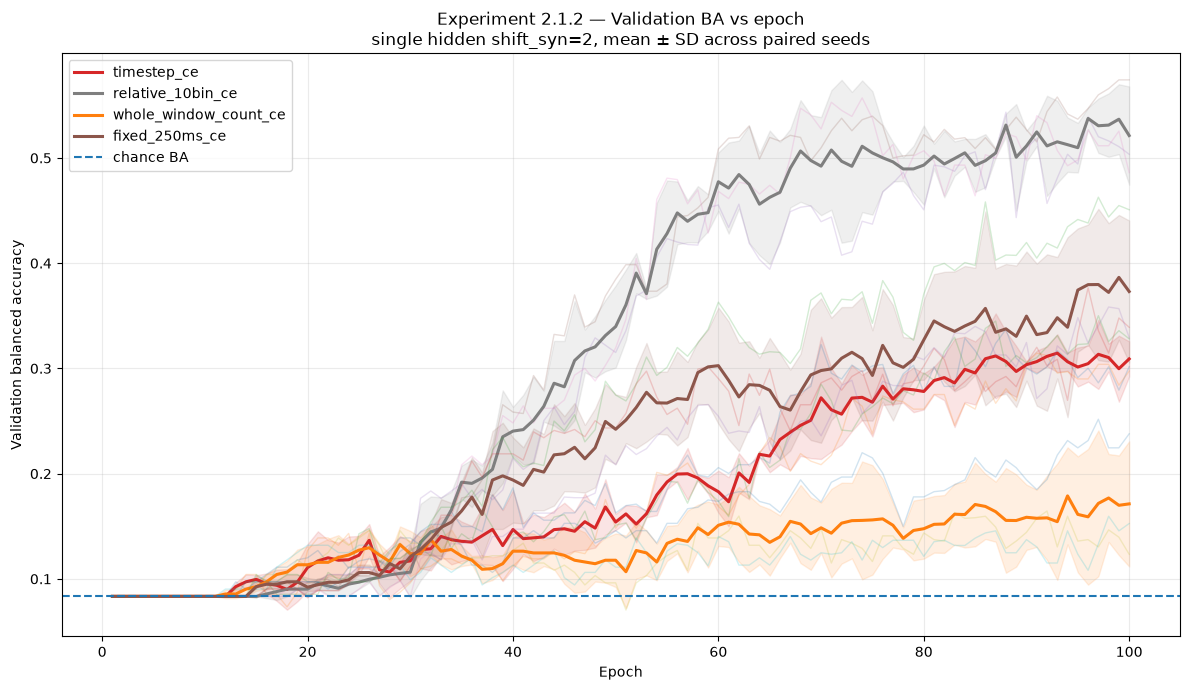

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

for objective in OBJECTIVES:
    sdf = histories_df[histories_df.objective == objective]

    for seed in SEEDS:
        seed_df = sdf[sdf.seed == seed].sort_values("epoch")
        ax.plot(
            seed_df["epoch"],
            seed_df["val_balanced_accuracy"],
            alpha=0.20,
            linewidth=1.0,
        )

    grouped = sdf.groupby("epoch")["val_balanced_accuracy"]
    mean_curve = grouped.mean()
    sd_curve = grouped.std()

    line, = ax.plot(
        mean_curve.index,
        mean_curve.values,
        linewidth=2.2,
        label=objective,
    )
    ax.fill_between(
        mean_curve.index,
        mean_curve.values - sd_curve.values,
        mean_curve.values + sd_curve.values,
        alpha=0.12,
        color=line.get_color(),
    )

ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title(
    "Experiment 2.1.2 — Validation BA vs epoch\n"
    f"single hidden shift_syn={HIDDEN_SHIFT_SYN}, mean ± SD across paired seeds"
)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
save_figure(fig, "val_ba_vs_epoch")
plt.show()


## 15. Validation/test objective comparison


Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/objective_val_test_ba.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/objective_val_test_ba.pdf


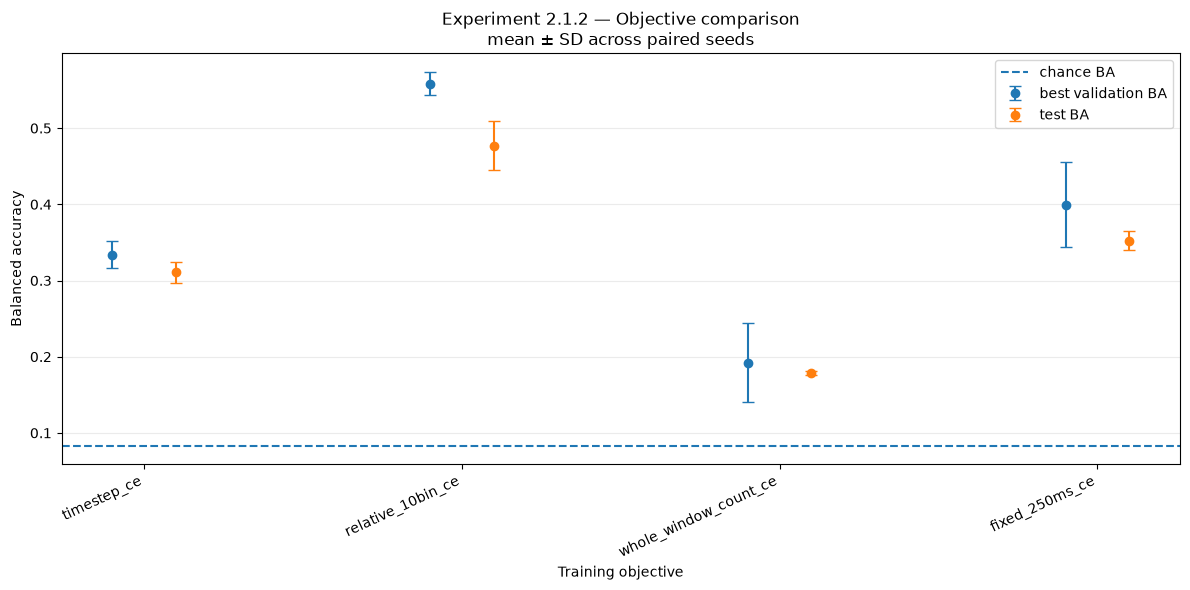

In [18]:
x = np.arange(len(OBJECTIVES), dtype=float)

val_means = []
val_sds = []
test_means = []
test_sds = []

for objective in OBJECTIVES:
    sdf = results_df[results_df.objective == objective]
    val_means.append(sdf["best_val_ba"].mean())
    val_sds.append(sdf["best_val_ba"].std(ddof=1))
    test_means.append(sdf["test_balanced_accuracy"].mean())
    test_sds.append(sdf["test_balanced_accuracy"].std(ddof=1))

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(
    x - 0.10,
    val_means,
    yerr=val_sds,
    marker="o",
    linestyle="none",
    capsize=4,
    label="best validation BA",
)
ax.errorbar(
    x + 0.10,
    test_means,
    yerr=test_sds,
    marker="o",
    linestyle="none",
    capsize=4,
    label="test BA",
)
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xticks(x, OBJECTIVES, rotation=25, ha="right")
ax.set_ylabel("Balanced accuracy")
ax.set_xlabel("Training objective")
ax.set_title(
    "Experiment 2.1.2 — Objective comparison\n"
    "mean ± SD across paired seeds"
)
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
save_figure(fig, "objective_val_test_ba")
plt.show()


## 16. Output firing-rate trajectory


Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/val_output_firing_rate_vs_epoch.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/val_output_firing_rate_vs_epoch.pdf


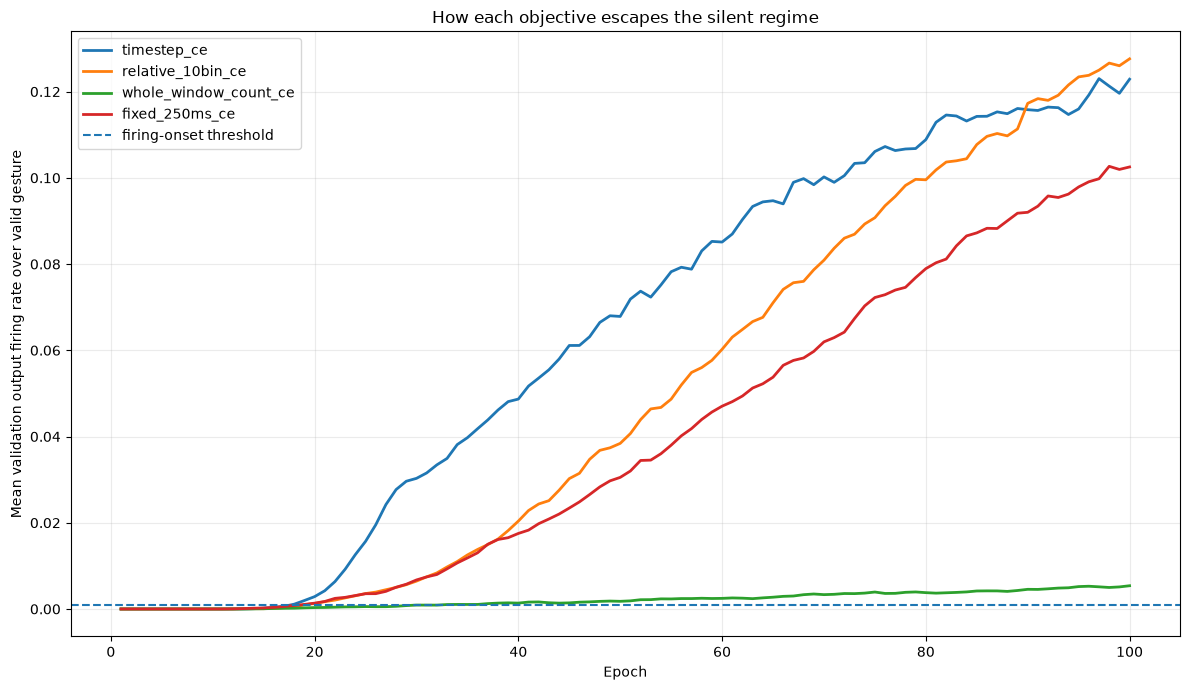

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

for objective in OBJECTIVES:
    sdf = histories_df[histories_df.objective == objective]
    mean_curve = sdf.groupby("epoch")["val_output_firing_rate"].mean()
    ax.plot(
        mean_curve.index,
        mean_curve.values,
        linewidth=2.0,
        label=objective,
    )

ax.axhline(
    FIRING_ONSET_THRESHOLD,
    linestyle="--",
    label="firing-onset threshold",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean validation output firing rate over valid gesture")
ax.set_title("How each objective escapes the silent regime")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
save_figure(fig, "val_output_firing_rate_vs_epoch")
plt.show()


## 17. Spike raster visualization

For each objective, select the paired-seed run with the highest validation BA, reload its best
checkpoint, and visualize the **same validation sample**. The true valid boundary is shown only as a
visual diagnostic. For `whole_window_count_ce` and `fixed_250ms_ce`, that boundary is not used in the
loss or native readout.


timestep_ce: raster uses seed=101, best val BA=0.3501
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_timestep_ce_seed_101.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_timestep_ce_seed_101.pdf


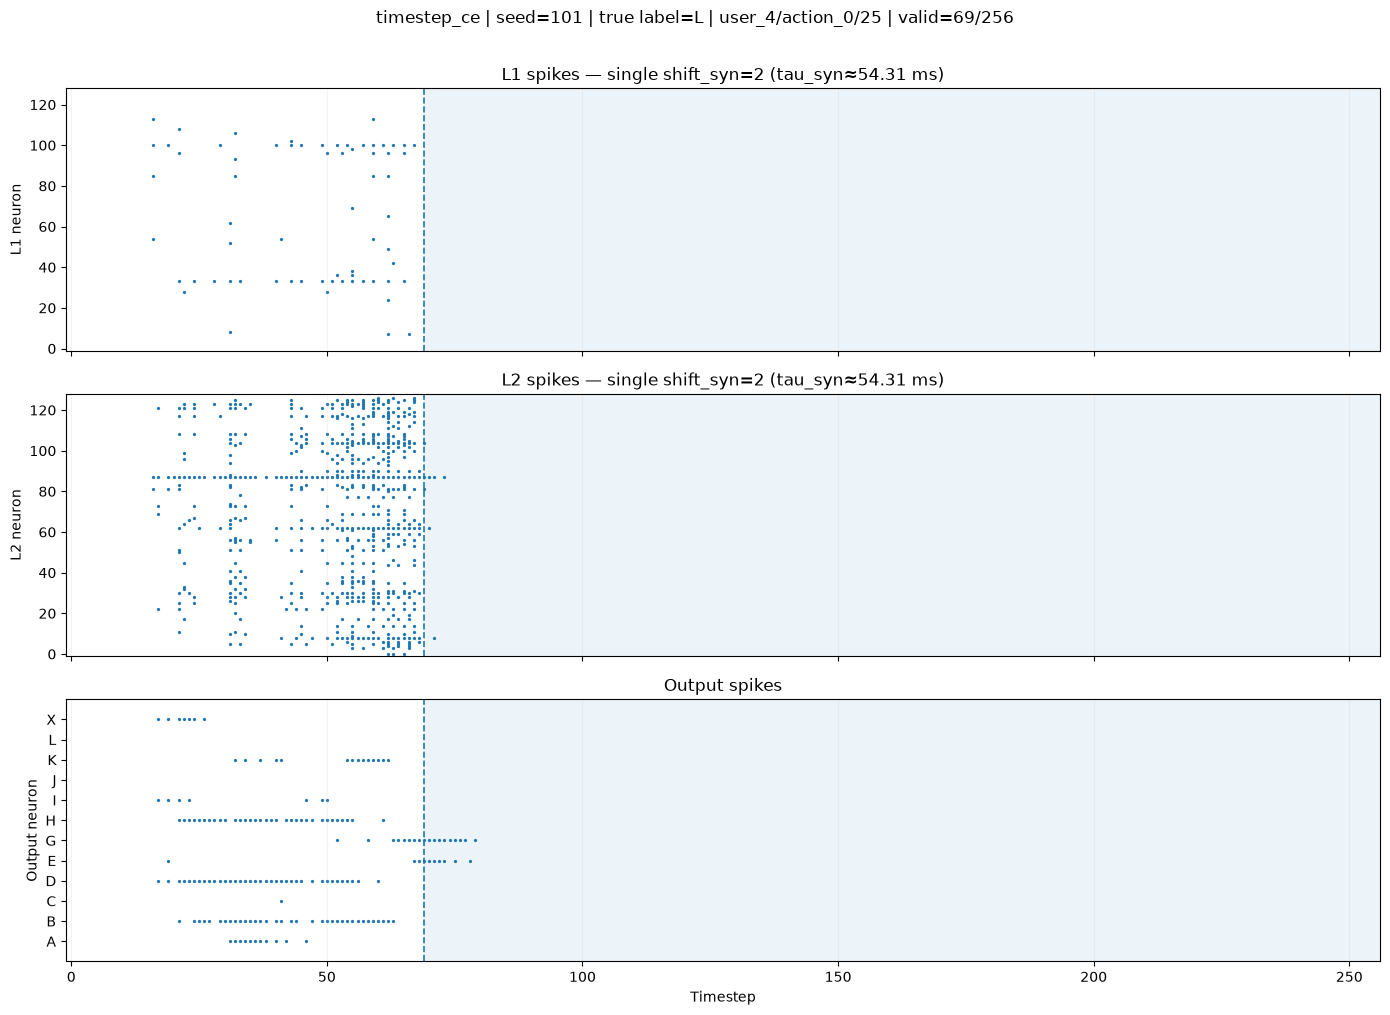

relative_10bin_ce: raster uses seed=23, best val BA=0.5742
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_relative_10bin_ce_seed_23.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_relative_10bin_ce_seed_23.pdf


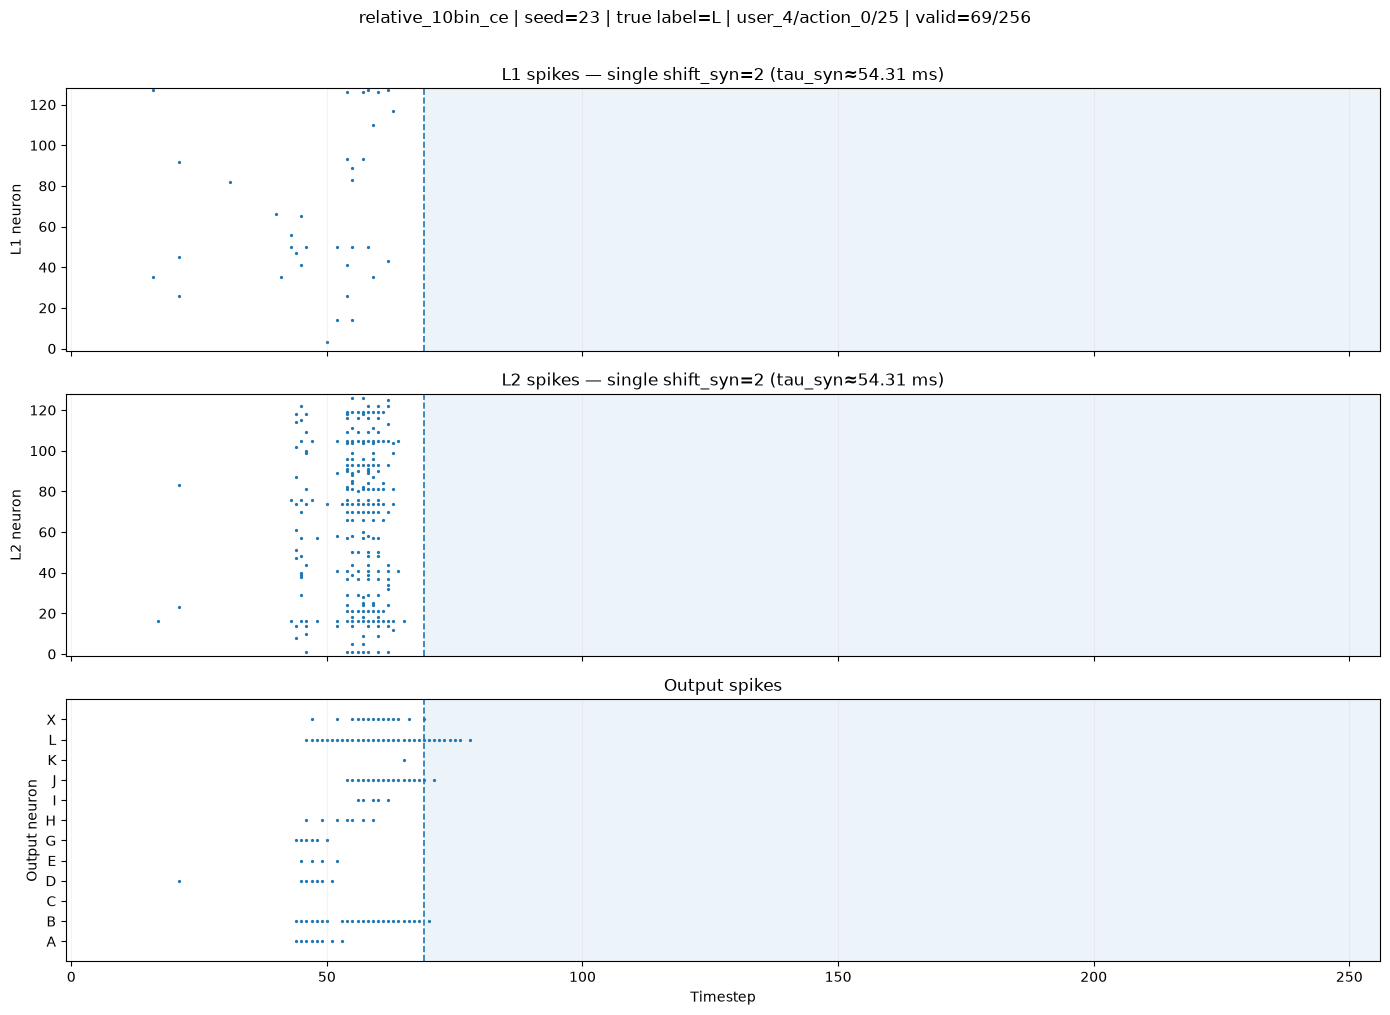

whole_window_count_ce: raster uses seed=101, best val BA=0.2517
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_whole_window_count_ce_seed_101.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_whole_window_count_ce_seed_101.pdf


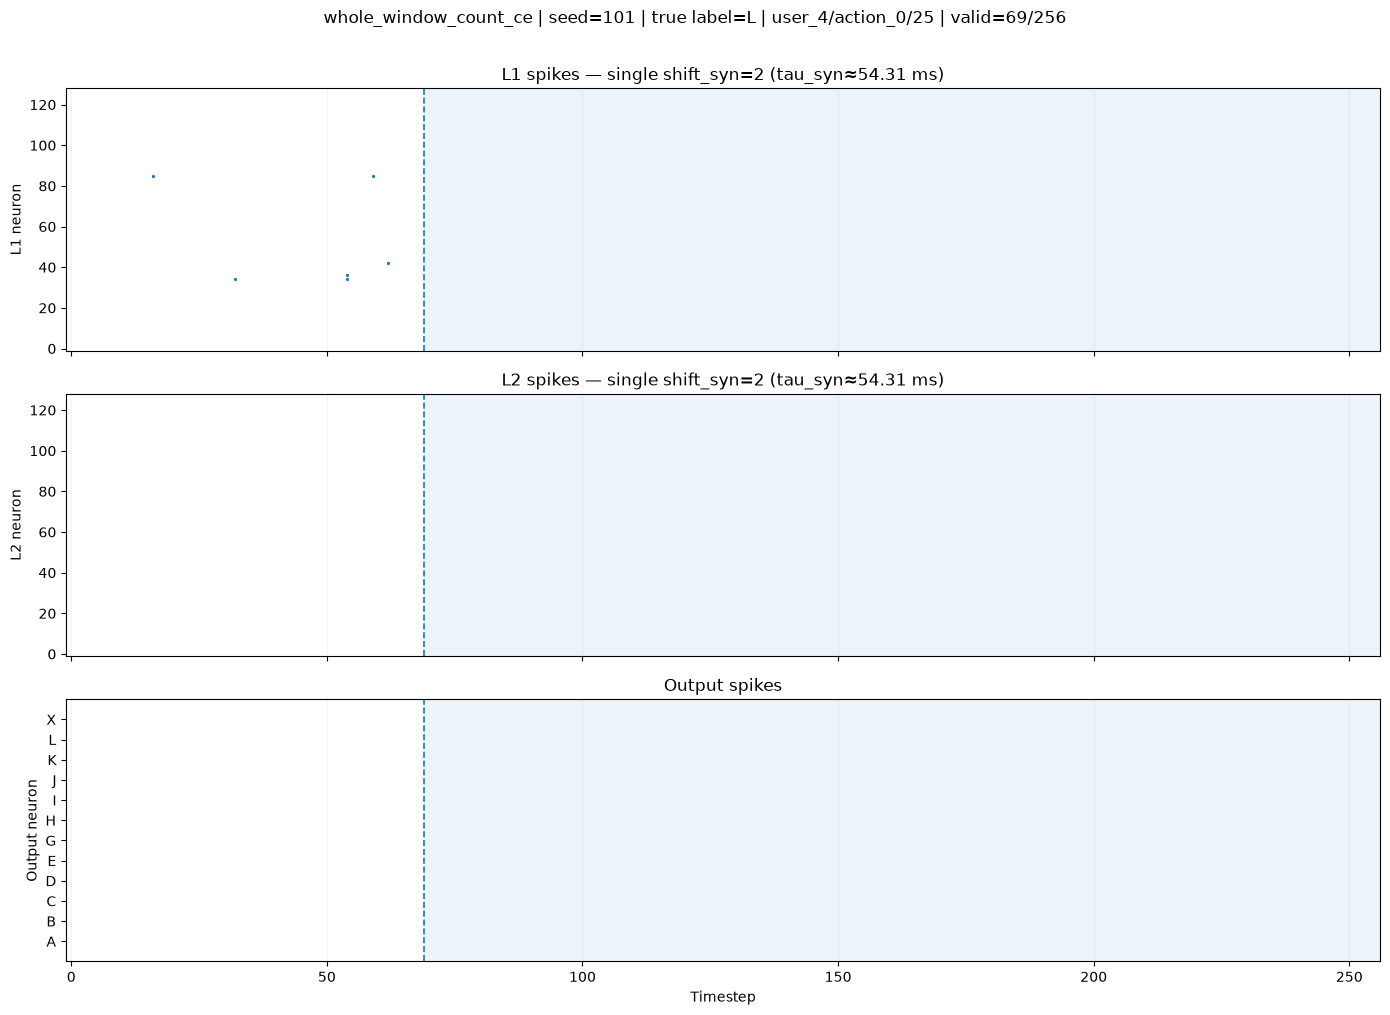

fixed_250ms_ce: raster uses seed=11, best val BA=0.4627
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_fixed_250ms_ce_seed_11.png
Saved figure: /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/figures/raster_fixed_250ms_ce_seed_11.pdf


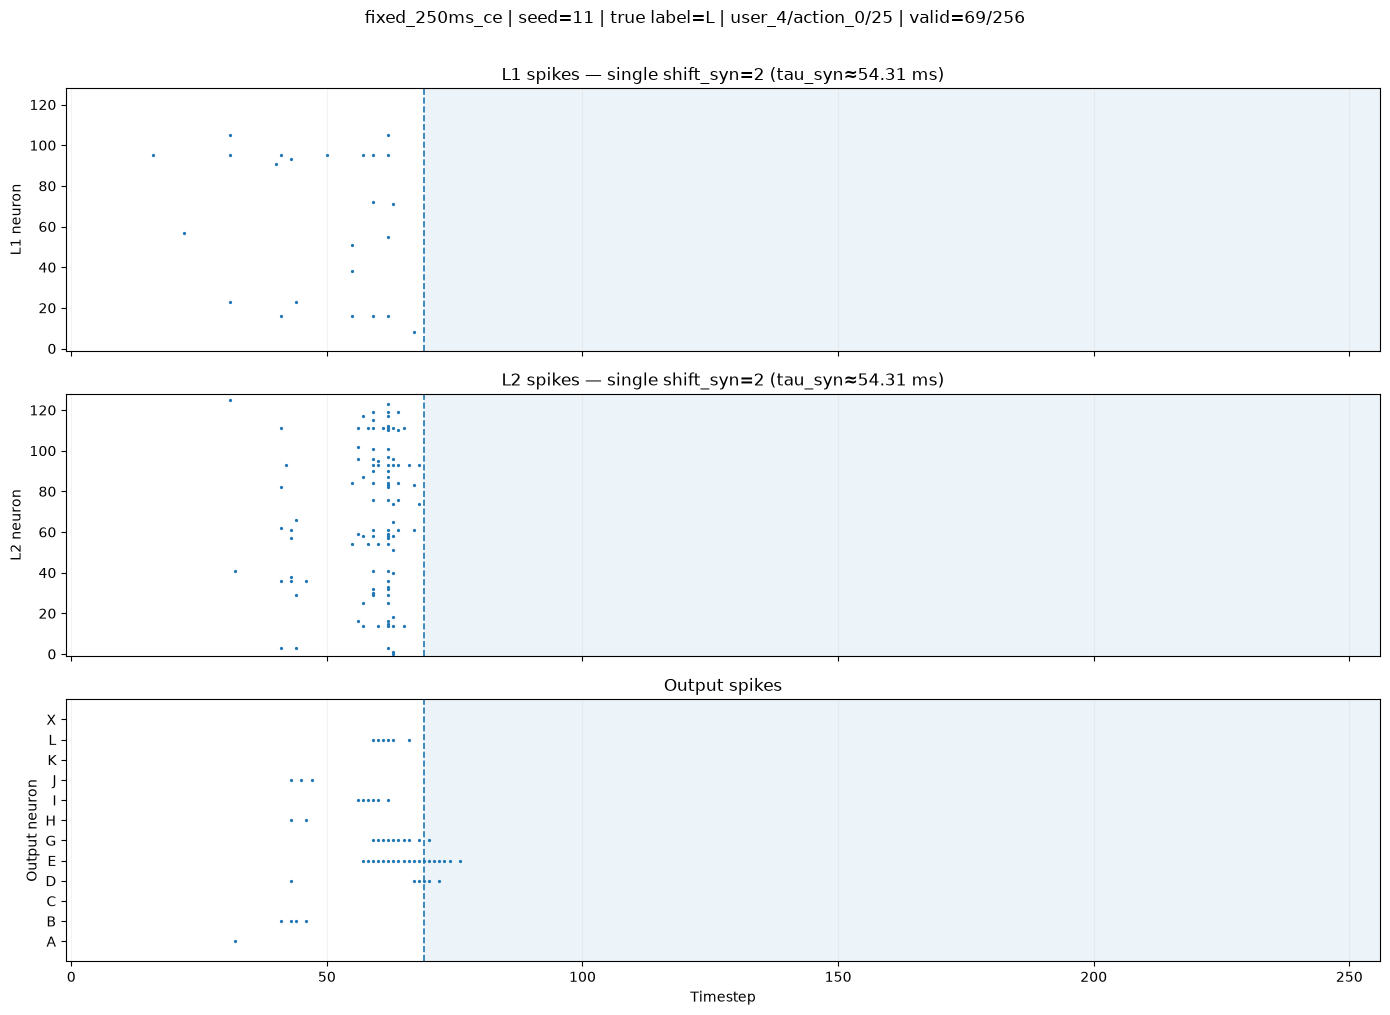

In [20]:
def load_best_checkpoint_model(objective: str, master_seed: int):
    loaded = load_completed_run(objective, master_seed)
    if loaded is None:
        raise FileNotFoundError(
            f"No completed checkpoint for objective={objective}, seed={master_seed}"
        )
    return loaded["model"]


def get_raster_sample(split_name="val", index=0):
    subset = FIXED_SPLIT_MANIFEST[
        FIXED_SPLIT_MANIFEST.split == split_name
    ]
    dataset = EventSNNDataset(data, subset)
    return dataset[index]


@torch.no_grad()
def collect_sample_activity(model, sample):
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    mask = sample["valid_mask"].unsqueeze(0).to(DEVICE)
    out = model(x, mask)
    return {
        "hidden_1": out["hidden_spikes"][0][0].cpu().numpy(),
        "hidden_2": out["hidden_spikes"][1][0].cpu().numpy(),
        "output": out["output_spikes"][0].cpu().numpy(),
    }


def raster_points(ax, spike_matrix):
    times, neurons = np.nonzero(spike_matrix > 0)
    if len(times):
        ax.scatter(times, neurons, s=7, marker=".")


def plot_spike_raster(
    model,
    sample,
    *,
    objective,
    master_seed,
):
    activity = collect_sample_activity(model, sample)
    valid_length = int(sample["valid_length"].item())
    total_length = int(sample["x"].shape[0])

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
        sharex=True,
    )

    for ax, key, label, neuron_count in (
        (axes[0], "hidden_1", "L1", HIDDEN_WIDTH),
        (axes[1], "hidden_2", "L2", HIDDEN_WIDTH),
        (axes[2], "output", "Output", NUM_CLASSES),
    ):
        raster_points(ax, activity[key])
        ax.axvline(valid_length, linestyle="--", linewidth=1.2)
        ax.axvspan(valid_length, total_length, alpha=0.08)
        ax.set_xlim(-1, total_length)
        ax.set_ylim(-1, neuron_count)
        ax.set_ylabel(f"{label} neuron")
        ax.grid(axis="x", alpha=0.15)

    axes[0].set_title(
        f"L1 spikes — single shift_syn={HIDDEN_SHIFT_SYN} "
        f"(tau_syn≈{HIDDEN_TAU_SYN_MS:.2f} ms)"
    )
    axes[1].set_title(
        f"L2 spikes — single shift_syn={HIDDEN_SHIFT_SYN} "
        f"(tau_syn≈{HIDDEN_TAU_SYN_MS:.2f} ms)"
    )
    axes[2].set_yticks(range(NUM_CLASSES))
    axes[2].set_yticklabels([IDX_TO_CLASS[i] for i in range(NUM_CLASSES)])
    axes[2].set_xlabel("Timestep")
    axes[2].set_title("Output spikes")

    label_idx = int(sample["label"].item())
    sample_id = sample["sample_id"]
    fig.suptitle(
        f"{objective} | seed={master_seed} | "
        f"true label={IDX_TO_CLASS[label_idx]} | {sample_id} | "
        f"valid={valid_length}/{total_length}",
        y=1.01,
    )

    plt.tight_layout()
    save_figure(
        fig,
        f"raster_{objective}_seed_{master_seed}",
    )
    plt.show()


RASTER_SPLIT = "val"
RASTER_SAMPLE_INDEX = 0
raster_sample = get_raster_sample(RASTER_SPLIT, RASTER_SAMPLE_INDEX)

for objective in OBJECTIVES:
    best_row = (
        results_df[results_df.objective == objective]
        .sort_values(
            ["best_val_ba", "val_loss_at_best_val_ba"],
            ascending=[False, True],
        )
        .iloc[0]
    )
    best_seed = int(best_row["seed"])

    print(
        f"{objective}: raster uses seed={best_seed}, "
        f"best val BA={best_row['best_val_ba']:.4f}"
    )

    raster_model = load_best_checkpoint_model(objective, best_seed)
    plot_spike_raster(
        raster_model,
        raster_sample,
        objective=objective,
        master_seed=best_seed,
    )

    del raster_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 18. Save results and provenance


In [21]:
EXPERIMENT_TITLE = (
    "Experiment 2.1.2 - Single-Tau SNN Training-Objective Comparison"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_path = RESULTS_DIR / "experiment_2_1_2_results.csv"
summary_path = RESULTS_DIR / "experiment_2_1_2_objective_summary.csv"
histories_path = RESULTS_DIR / "experiment_2_1_2_all_histories.csv"
paired_path = RESULTS_DIR / "experiment_2_1_2_paired_test_ba.csv"
metadata_path = RESULTS_DIR / "experiment_2_1_2_provenance.json"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)
histories_df.to_csv(histories_path, index=False)
paired_test_ba.to_csv(paired_path)

provenance = {
    "title": EXPERIMENT_TITLE,
    "experiment_id": EXPERIMENT_ID,
    "dataset_roots": [str(path) for path in DATASET_ROOTS],
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    "input_channels": int(INPUT_CHANNELS),
    "num_classes": int(NUM_CLASSES),
    "classes": labels_sorted,
    "sampling_rate_hz": float(SAMPLING_RATE_HZ),
    "padded_length": int(PADDED_LENGTH),
    "split_seed": int(SPLIT_SEED),
    "training_seeds": list(SEEDS),
    "expected_training_runs": int(EXPECTED_TRAINING_RUNS),
    "hidden_layers": 2,
    "neurons_per_layer": [int(HIDDEN_WIDTH), int(HIDDEN_WIDTH)],
    "hidden_shift_syn": int(HIDDEN_SHIFT_SYN),
    "hidden_alpha": float(HIDDEN_ALPHA),
    "hidden_tau_syn_ms": float(HIDDEN_TAU_SYN_MS),
    "tau_mem_ms": float(TAU_MEM_MS),
    "tau_syn_output_ms": float(TAU_SYN_OUT_MS),
    "threshold": float(THRESHOLD),
    "surrogate_slope": float(SURROGATE_SLOPE),
    "reset_mechanism": RESET_MECHANISM,
    "snn_linear_bias": False,
    "learn_alpha": False,
    "learn_beta": False,
    "learn_threshold": False,
    "objectives": list(OBJECTIVES),
    "objective_uses_valid_length": OBJECTIVE_USES_VALID_LENGTH,
    "n_relative_bins": int(N_RELATIVE_BINS),
    "fixed_bin_requested_ms": float(FIXED_BIN_MS),
    "fixed_bin_steps": int(FIXED_BIN_STEPS),
    "fixed_bin_effective_ms": float(FIXED_BIN_EFFECTIVE_MS),
    "fixed_bin_count": int(FIXED_BIN_COUNT),
    "num_epochs": int(NUM_EPOCHS),
    "early_stopping": False,
    "checkpoint_selection": (
        "maximum validation balanced accuracy; lower validation loss as tie-break"
    ),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "spike_regularization": float(SPIKE_REGULARIZATION),
    "firing_onset_threshold": float(FIRING_ONSET_THRESHOLD),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, sort_keys=True)

print("=" * 100)
print(EXPERIMENT_TITLE)
print("=" * 100)
print(f"Architecture: {INPUT_CHANNELS} -> {HIDDEN_WIDTH} -> {HIDDEN_WIDTH} -> {NUM_CLASSES}")
print(
    f"Hidden shift_syn={HIDDEN_SHIFT_SYN}, "
    f"tau_syn≈{HIDDEN_TAU_SYN_MS:.3f} ms"
)
print("Objectives:", OBJECTIVES)
print("Objective valid-length use:", OBJECTIVE_USES_VALID_LENGTH)
print("Training seeds:", SEEDS)
print("Training runs:", EXPECTED_TRAINING_RUNS)
print("Split seed:", SPLIT_SEED)
print("Saved:")
for path in (
    results_path,
    summary_path,
    histories_path,
    paired_path,
    metadata_path,
):
    print(" ", path)


Experiment 2.1.2 - Single-Tau SNN Training-Objective Comparison
Architecture: 30 -> 128 -> 128 -> 12
Hidden shift_syn=2, tau_syn≈54.313 ms
Objectives: ('timestep_ce', 'relative_10bin_ce', 'whole_window_count_ce', 'fixed_250ms_ce')
Objective valid-length use: {'timestep_ce': True, 'relative_10bin_ce': True, 'whole_window_count_ce': False, 'fixed_250ms_ce': False}
Training seeds: (11, 23, 101)
Training runs: 12
Split seed: 12345
Saved:
  /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/experiment_2_1_2_results.csv
  /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/experiment_2_1_2_objective_summary.csv
  /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/experiment_2_1_2_all_histories.csv
  /home/ted/project/writingRing/notebooks/artifacts/experiment_2_1_2_single_tau_objective_comparison/experiment_2_1_2_paired_test_ba.csv
  /home/ted/project

## Interpretation checklist

The primary comparison is the paired three-seed difference among the four objectives under the same
single-timescale 128→128 feed-forward SNN.

Check:

- Do all objectives escape chance-level validation BA and the silent regime?
- **`timestep_ce` vs `relative_10bin_ce`:** does dense timestep supervision or relative gesture-phase
  structure generalize better when both may use the true valid boundary?
- **`whole_window_count_ce` vs `fixed_250ms_ce`:** with neither objective using the valid boundary,
  does preserving absolute-time structure improve over total spike count alone?
- **`relative_10bin_ce` vs `fixed_250ms_ce`:** how much performance is gained by gesture-relative
  normalization and access to the gesture boundary compared with a boundary-free absolute-time readout?
- Does `relative_10bin_ce` or `fixed_250ms_ce` achieve high native BA while the common whole-window
  count diagnostic remains low? If so, the learned information is primarily temporal rather than a
  class-selective total-count code.
- Are zero-input firing rates exactly zero?
- Are hidden/output firing rates healthy rather than silent or saturated?

### Intended conclusion structure

This experiment should select the Phase-B training objective before architecture sweeps. The fixed-window
pair is especially important for future online inference because it removes oracle knowledge of gesture end
from both the whole-count and fixed-duration objectives.
